In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from agents.analyst import analyst_node
from agents.extended_analyst import extended_analyst_node
from agents.first_hitl import first_hitl_analyst_node
from agents.сorrelation import correlation_node
from graph.agent_state import AgentState
from graph.graph_helpers import run_graph_with_hitl

In [2]:
builder = StateGraph(AgentState)

builder.add_node("analyst_node", analyst_node)
builder.add_node("extended_analyst_node", extended_analyst_node)
builder.add_node("first_hitl_analyst_node", first_hitl_analyst_node)
builder.add_node("correlation_node", correlation_node)


builder.add_edge(START, "analyst_node")
builder.add_edge("analyst_node", "extended_analyst_node")
builder.add_edge("extended_analyst_node", "first_hitl_analyst_node")
builder.add_edge("first_hitl_analyst_node", "correlation_node")
builder.add_edge("correlation_node", END)

graph = builder.compile()

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional
from langgraph.types import interrupt
from langchain_core.prompts import ChatPromptTemplate
from graph.agent_state import AgentState
from llm import llm

class LeakageDetection(BaseModel):
    columns_to_drop: Optional[list[str]] = Field(description="Список колонок, которые пользователь не считает ликующими и хочет удалить из списка")
    сolumns_to_add: Optional[list[str]] = Field(description="Список колонок, которые пользователь хочет добавить в список")

parse_leakage_answer_llm = ChatPromptTemplate.from_messages([
    ("system", """
     Пользователь отвечает на вопрос о том, какие фичи являются data leak, а какие нет.
     Текущее значение: {current_value}
     Список колонок: {cols}
     
     Тебе нужно заполнить два списка:
     1. columns_to_drop если пользователь указал, какие колонки нужно убарть, либо это все колонки, если пользователь
     явно сказал, что в предложенном списке все колонки корректные и мы не считаем их data leak
     2. columns_to_keep если пользователь дополнительно указал, какие колонки нужно дабавить

     Пользователь может написать название без ковычек, тебе нужно это обработать.
     Используй только названия колонок, не придумывай. Если пользователь назвал несуществующую
     колонку или написал бессмысленный текст,то игнорируй такое сообщение
     """),
    ("human", "{user_input}")
]) | llm.with_structured_output(LeakageDetection)

def should_check_leakage(state: AgentState) -> dict:
    if state["leakage_candidates"]:
        return "second_hitl_node"
    return "strategy_agent"

def hitl_leakage_node(state: AgentState) -> dict:
    # тут показываем leakage_candidates, парсим ответ и формируем confirmed_drop_columns
    # как смесь текущих колонок c ликом и id
    answer = interrupt({
        "question": "Подтвердите колонки с даталиком для удаления",
        "current_value": state["leakage_candidates"],
        "cols": state["df_columns"],
        "hint": "Опишите, что нужно оставить или убрать. Можно согласиться со всем или всем удалить"
    })

    parsed_answer = parse_leakage_answer_llm.invoke({
        "current_value": state["leakage_candidates"],
        "cols": state["df_columns"],
        "user_input": answer
    })
    candidates = set(state["leakage_candidates"])
    drop = set(parsed_answer.columns_to_drop or [])
    add = set(parsed_answer.columns_to_keep or [])
    ids = set(state["confirmed_id_columns"] or [])
    confirmed_drop_columns = list(candidates - drop + add + ids)
    return {
        "confirmed_drop_columns": confirmed_drop_columns
    }

def hitl_confirm_drops_node(state: AgentState) -> dict:
    #верифицируем итоговый список колон на удаление
    pass



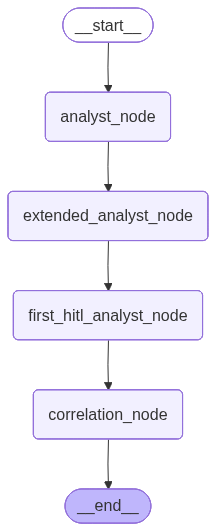

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

In [16]:
from langgraph.checkpoint.memory import MemorySaver

query = """
    Во вложении датасет, который описывает данные банковских клиентов.
    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status
    Уникальный идентификатор клиента - Application ID
"""

initial_state = {"messages": [HumanMessage(content=query)], "file_path": "test_data/Train_Set_90621.parquet"}
config={"configurable": {"thread_id": "test"}}

graph = builder.compile(checkpointer=MemorySaver())

result = run_graph_with_hitl(graph, initial_state, config)


Подтвердите таргет для обучения
current_value: Default_Status
hint: Введите название колонки или 'ok' для подтверждения

Подтвердите колонки-идентификаторы для удаления
current_value: ['Application ID', 'Company Branch Code']
hint: Введите список через запятую или 'ok' для подтверждения


In [17]:
result

{'messages': [HumanMessage(content='\n    Во вложении датасет, который описывает данные банковских клиентов.\n    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status\n    Уникальный идентификатор клиента - Application ID\n', additional_kwargs={}, response_metadata={}, id='602d6b2b-949c-4bf4-b5b6-58d4ffe8e35d'),
  AIMessage(content='По данным заявок на бизнес-кредит требуется предсказывать вероятность/класс дефолта по заявке. В датасете представлены параметры банка и бизнеса (тип банка, штат, отраслевой код, сумма, срок, занятость, документы и т.д.), а целевая переменная — Default_Status. Модель должна использовать эти признаки для определения, будет ли заявка в классе дефолта.', additional_kwargs={}, response_metadata={}, id='80e7bfae-fba5-4c30-a694-c424e18f73d3', tool_calls=[], invalid_tool_calls=[])],
 'file_path': 'test_data/Train_Set_90621.parquet',
 'df_columns': ['Application ID',
  'Bank Masked',
  'Bank Type',
  'Approved_Timestamp',
  'Na